In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [4]:
# Load dataset
data = pd.read_csv('/content/A_Z Handwritten Data.csv')

In [5]:
# Separate features and labels
X = data.drop('0', axis=1).values
y = data['0'].values
X = X / 255.0
X = X.reshape(-1, 28, 28, 1)
y = to_categorical(y, num_classes=26)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 297960
Testing samples: 74490


In [6]:
# build CNN
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(26, activation='softmax'))
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#train and save the trained data
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_test, y_test))
model.save('ML_Trained_model.h5')

Epoch 1/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 278s 118ms/step - accuracy: 0.8209 - loss: 0.6339 - val_accuracy: 0.9766 - val_loss: 0.0830
Epoch 2/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 312s 114ms/step - accuracy: 0.9585 - loss: 0.1492 - val_accuracy: 0.9832 - val_loss: 0.0606
Epoch 3/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 331s 118ms/step - accuracy: 0.9684 - loss: 0.1124 - val_accuracy: 0.9860 - val_loss: 0.0530
Epoch 4/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 320s 117ms/step - accuracy: 0.9746 - loss: 0.0893 - val_accuracy: 0.9879 - val_loss: 0.0475
Epoch 5/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 283s 122ms/step - accuracy: 0.9784 - loss: 0.0762 - val_accuracy: 0.9890 - val_loss: 0.0423
Epoch 6/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 283s 121ms/step - accuracy: 0.9803 - loss: 0.0681 - val_accuracy: 0.9899 - val_loss: 0.0398
Epoch 7/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 281s 121ms/step - accuracy: 0.9829 - loss: 0.0584 - val_accuracy: 0.9902 - val_loss: 0.0393
Epoch 8/20
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 305s 113ms/step - ac

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted letter: H
Confidence: 56.5%


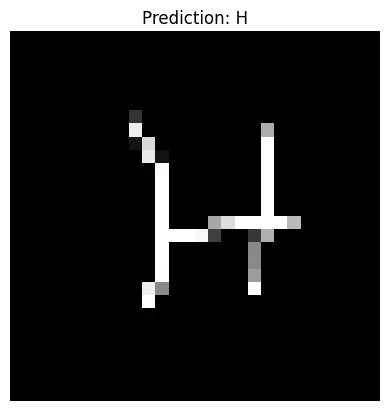

In [15]:
#predict from the trained model h5
import numpy as np
import cv2
from tensorflow.keras.models import load_model

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = 255 - img
    img = cv2.resize(img, (28, 28))
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=(0, -1))
sample_path = 'ha.png'  # Replace with your image
processed_img = preprocess_image(sample_path)
prediction = model.predict(processed_img)
predicted_letter = chr(np.argmax(prediction) + 65)
print(f"Predicted letter: {predicted_letter}")
print(f"Confidence: {np.max(prediction):.1%}")
import matplotlib.pyplot as plt
plt.imshow(processed_img[0,:,:,0], cmap='gray')
plt.title(f"Prediction: {predicted_letter}")
plt.axis('off')
plt.show()

In [1]:
#multi random sample prediction
labels = list(string.ascii_uppercase)
num_samples = 12
indices = np.random.choice(X_test.shape[0], num_samples, replace=False)
sample_images = X_test[indices]
sample_labels = y_test[indices]


predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(sample_labels, axis=1)

plt.figure(figsize=(12, 6))
for i in range(num_samples):
    plt.subplot(3, 4, i+1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {labels[predicted_classes[i]]}\nTrue: {labels[true_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'string' is not defined

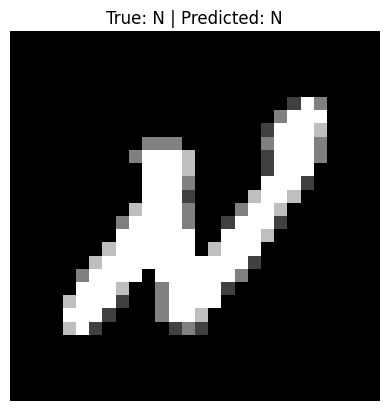

In [19]:
# random sample prediction
sample_idx = np.random.randint(0, len(X_test))
sample_image = X_test[sample_idx]
input_image = np.expand_dims(sample_image, axis=0)
prediction = model.predict(input_image, verbose=0)
predicted_class = np.argmax(prediction)
true_letter = chr(true_label + 65)
predicted_letter = chr(predicted_class + 65)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"True: {true_letter} | Predicted: {predicted_letter}")
plt.axis('off')
plt.show()

In [20]:
#evaluation

y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
print(f"Test Accuracy: {test_acc:.2%}")
print("\nClassification Report (A-Z):")
print(classification_report(y_true, y_pred_classes,
                          target_names=[chr(i+65) for i in range(26)],
                          digits=3))

# Confusion Matrix
plt.figure(figsize=(15,12))
sns.heatmap(confusion_matrix(y_true, y_pred_classes),
           annot=True, fmt='d',
           xticklabels=[chr(i+65) for i in range(26)],
           yticklabels=[chr(i+65) for i in range(26)])
plt.title("Confusion Matrix (A-Z)")
plt.show()

1126/1126 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step
Test Accuracy: 92.94%

Classification Report (A-Z):


ValueError: Number of classes, 15, does not match size of target_names, 26. Try specifying the labels parameter